In [2]:
# Import library dasar untuk pengolahan data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# ==========================================
# 2. DATASET COLLECTION
# ==========================================
print("--- Memuat Dataset ---")
df = pd.read_csv('tmdb_movies_dataset.csv')
display(df.head())

# ==========================================
# 3. DATA UNDERSTANDING (EDA)
# ==========================================
print("\n--- a. Mengecek Struktur Dataset ---")
print(df.info())

print("\n--- b. Mengecek Missing Values ---")
print(df.isnull().sum())

print("\n--- c. Mengecek Duplicate Data ---")
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

# Menghapus duplikat (jika ada)
df = df.drop_duplicates()

print("\n--- d. Analisis Statistik Deskriptif ---")
display(df.describe())

--- Memuat Dataset ---


,movie_id,title,release_date,vote_count,popularity,rating
0,798645,The Running Man,11/11/2025,598,418.0257,6.872
1,1084242,Zootopia 2,11/26/2025,643,382.4108,7.635
2,1223601,Sisu: Road to Revenge,10/21/2025,115,386.9594,7.700
3,812583,Wake Up Dead Man: A Knives Out Mystery,11/26/2025,697,344.9733,7.334
4,1387382,Hunting Season,12/5/2025,33,227.3166,6.985



--- a. Mengecek Struktur Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      4000 non-null   int64  
 1   title         4000 non-null   object 
 2   release_date  3984 non-null   object 
 3   vote_count    4000 non-null   int64  
 4   popularity    4000 non-null   float64
 5   rating        4000 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 187.6+ KB
None

--- b. Mengecek Missing Values ---
movie_id         0
title            0
release_date    16
vote_count       0
popularity       0
rating           0
dtype: int64

--- c. Mengecek Duplicate Data ---
Jumlah data duplikat: 766

--- d. Analisis Statistik Deskriptif ---


,movie_id,vote_count,popularity,rating
count,3.234000e+03,3234.000000,3234.000000,3234.000000
mean,4.286730e+05,2638.127706,11.586798,6.082767
std,4.555008e+05,4883.344352,19.718716,1.960072
min,5.000000e+00,0.000000,3.508900,0.000000
25%,2.037725e+04,19.000000,6.640050,5.700000
50%,2.761505e+05,342.000000,7.662650,6.558000
75%,7.583570e+05,2967.250000,9.997075,7.232000
max,1.591771e+06,38409.000000,418.025700,10.000000


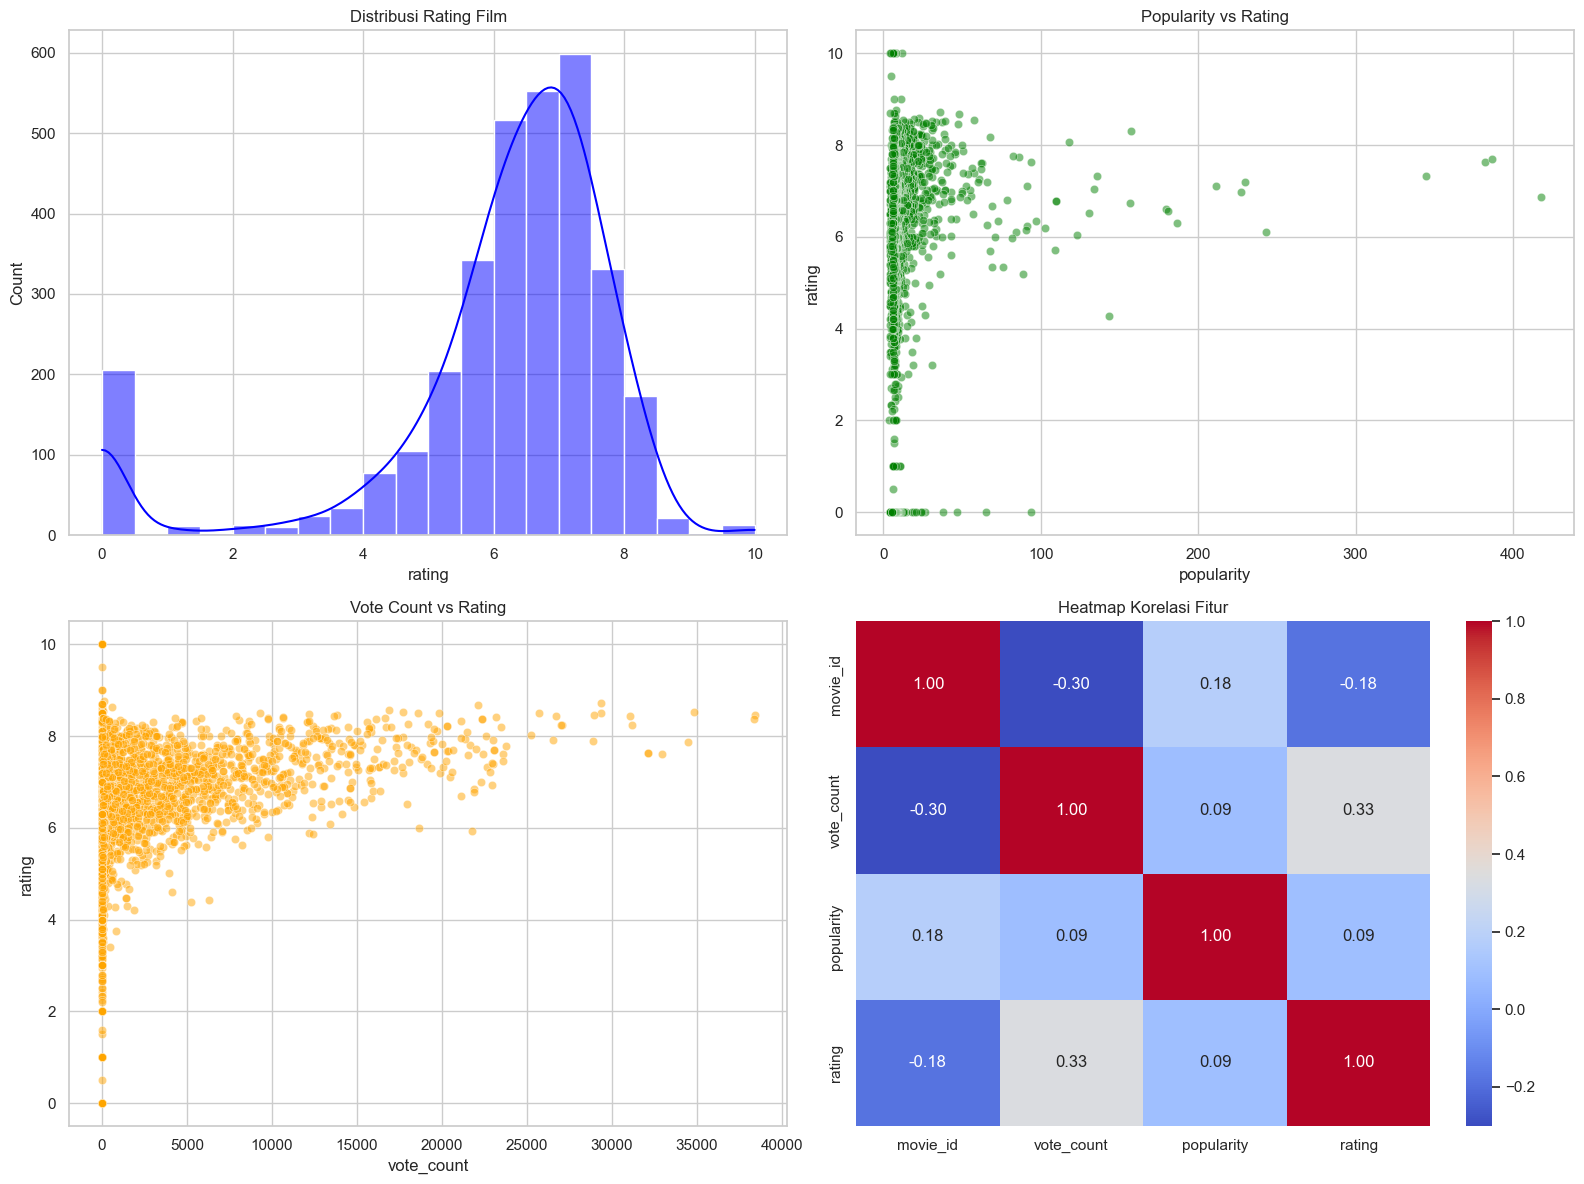

In [4]:
# --- e. Visualisasi Data ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram distribusi rating
sns.histplot(df['rating'], bins=20, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Distribusi Rating Film')

# 2. Scatter plot popularity vs rating
sns.scatterplot(x='popularity', y='rating', data=df, ax=axes[0, 1], alpha=0.5, color='green')
axes[0, 1].set_title('Popularity vs Rating')

# 3. Scatter plot vote_count vs rating
sns.scatterplot(x='vote_count', y='rating', data=df, ax=axes[1, 0], alpha=0.5, color='orange')
axes[1, 0].set_title('Vote Count vs Rating')

# 4. Heatmap korelasi fitur numerik
# Memilih hanya kolom numerik untuk korelasi
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap Korelasi Fitur')

plt.tight_layout()
plt.show()

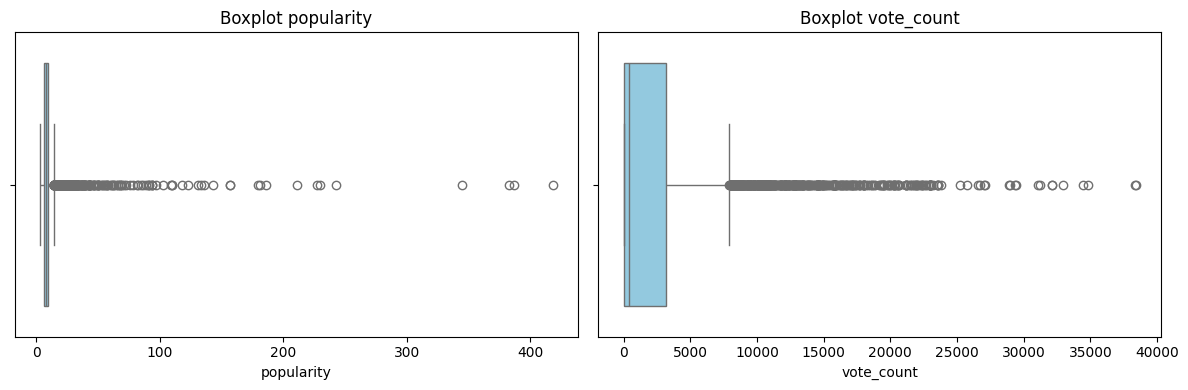

Jumlah data sebelum hapus outlier: 3984
Jumlah data setelah hapus outlier: 2822

Ukuran Data Latih (Train): 2257 baris
Ukuran Data Uji (Test)   : 565 baris


In [5]:
# ==========================================
# 4. DATA PREPROCESSING
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# --- c. Handling Missing Values & d. Data Type Conversion ---
# Mengubah string menjadi datetime dan menghapus baris yang tanggal rilisnya kosong
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])

# --- b. Feature Engineering ---
# Mengekstrak tahun dan bulan rilis sesuai pipeline
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month  # Fitur tambahan agar prediksi XGBoost lebih akurat

# --- a. Feature Selection ---
# Memilih fitur yang akan digunakan sesuai pipeline
features = ['popularity', 'vote_count', 'release_year', 'release_month']
target = 'rating'

# Membuat dataset baru hanya dengan fitur yang dipilih dan memastikan tidak ada nilai kosong (NaN)
df_model = df[features + [target]].dropna()

# --- e. Outlier Handling (Mendeteksi dengan Boxplot) ---
plt.figure(figsize=(12, 4))
for i, col in enumerate(['popularity', 'vote_count']):
    plt.subplot(1, 2, i+1)
    sns.boxplot(x=df_model[col], color='skyblue')
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

# Menghapus Outlier ekstrem menggunakan metode IQR (Interquartile Range)
Q1 = df_model.quantile(0.25)
Q3 = df_model.quantile(0.75)
IQR = Q3 - Q1

# Filter data yang berada di dalam batas IQR (menghapus yang terlalu ekstrem)
# Batas biasanya 1.5 * IQR, kita gunakan di sini agar model lebih stabil
df_clean = df_model[~((df_model < (Q1 - 1.5 * IQR)) | (df_model > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Jumlah data sebelum hapus outlier: {len(df_model)}")
print(f"Jumlah data setelah hapus outlier: {len(df_clean)}")

# --- f. Train-Test Split (80% : 20%) ---
X = df_clean[features]
y = df_clean[target]

# Split data dengan rasio 80:20 sesuai pipeline, ditambahkan random_state agar acakannya konsisten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"\nUkuran Data Latih (Train): {X_train.shape[0]} baris")
print(f"Ukuran Data Uji (Test)   : {X_test.shape[0]} baris")

In [6]:
# =========================================================
# 5, 6, 7, 8, 9. PIPELINE, TRAINING & EXPERIMENT TRACKING
# =========================================================
import mlflow
import mlflow.sklearn
import numpy as np
import time
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Setup MLflow Tracking ---
mlflow.set_experiment("Eksperimen_Prediksi_Rating_Film")

# Inisialisasi masing-masing algoritma
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Menggabungkan ketiganya menjadi satu Super Model (Voting Regressor)
ensemble_model = VotingRegressor(estimators=[
    ('Random_Forest', rf_model),
    ('Gradient_Boosting', gb_model),
    ('XGBoost', xgb_model)
])

# Masukkan ke dalam dictionary untuk di-loop
models = {
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
    "Ensemble Voting (Gabungan)": ensemble_model
}

results = []

print("--- Memulai Training & MLflow Tracking ---")
for name, model in models.items():
    # Memulai pencatatan MLflow untuk masing-masing model
    with mlflow.start_run(run_name=f"Train_{name.replace(' ', '_')}"):
        print(f"Sedang melatih {name}...")
        start_time = time.time()
        
        # 6. Model Training
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # 10. Prediksi untuk Evaluasi
        y_pred = model.predict(X_test)
        
        # Hitung Metrik Evaluasi Regresi
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        # 7, 8, 9. Log Parameter, Metrik, dan Model ke MLflow
        mlflow.log_param("model_name", name)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)
        mlflow.log_metric("training_time", training_time)
        mlflow.sklearn.log_model(model, artifact_path="model")
        
        # Simpan hasil ke dalam list untuk komparasi lokal (tabel)
        results.append({
            "Model": name,
            "MAE": round(mae, 3),
            "RMSE": round(rmse, 3),
            "R2 Score": round(r2, 3),
            "Waktu Training (detik)": round(training_time, 2)
        })
        print(f"✅ {name} selesai!")

# Menampilkan tabel komparasi di Jupyter Notebook
print("\n🏆 Hasil Perbandingan Model:")
df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
display(df_results)

2026/05/12 22:34:51 INFO mlflow.tracking.fluent: Experiment with name 'Eksperimen_Prediksi_Rating_Film' does not exist. Creating a new experiment.


--- Memulai Training & MLflow Tracking ---
Sedang melatih Random Forest...


2026/05/12 22:34:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 22:34:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest selesai!
Sedang melatih Gradient Boosting...


2026/05/12 22:35:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 22:35:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/05/12 22:35:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 22:35:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ XGBoost selesai!
Sedang melatih Ensemble Voting (Gabungan)...


2026/05/12 22:35:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 22:35:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Ensemble Voting (Gabungan) selesai!

🏆 Hasil Perbandingan Model:


,Model,MAE,RMSE,R2 Score,Waktu Training (detik)
0,Random Forest,0.599,0.749,0.400,0.85
1,Ensemble Voting (Gabungan),0.607,0.764,0.376,1.64
2,Gradient Boosting,0.618,0.783,0.345,0.65
3,XGBoost,0.620,0.784,0.343,0.18


In [7]:
# =========================================================
# 5, 6, 7, 8, 9. PIPELINE, TRAINING & EXPERIMENT TRACKING
# =========================================================
import mlflow
import mlflow.sklearn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inisialisasi masing-masing algoritma
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Menggabungkan ketiganya menjadi Ensemble
ensemble_model = VotingRegressor(estimators=[
    ('Random_Forest', rf_model),
    ('Gradient_Boosting', gb_model),
    ('XGBoost', xgb_model)
])

# Masukkan ke dalam dictionary
models = {
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
    "Ensemble Voting": ensemble_model
}

results = []

print("--- Memulai Training Model ---")
for name, model in models.items():
    print(f"Sedang melatih {name}...")
    start_time = time.time()
    
    # Melatih Model
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Prediksi
    y_pred = model.predict(X_test)
    
    # Evaluasi
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Simpan hasil ke dalam list 'results' agar bisa dibaca oleh kodemu di bawahnya
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "Waktu Training (detik)": training_time
    })
    print(f"✅ {name} selesai!")

# ==========================================
# (KODEMU DIMULAI DI SINI)
# 10, 11. MODEL EVALUATION & COMPARISON
# ==========================================
print("\n--- Perbandingan Performa Model ---")
# Urutkan berdasarkan RMSE terkecil (error paling sedikit = paling bagus)
df_results = pd.DataFrame(results).sort_values(by="RMSE", ascending=True)
display(df_results)
# ... dan seterusnya ikuti dengan kode visualisasi milikmu ...

--- Memulai Training Model ---
Sedang melatih Random Forest...
✅ Random Forest selesai!
Sedang melatih Gradient Boosting...
✅ Gradient Boosting selesai!
Sedang melatih XGBoost...
✅ XGBoost selesai!
Sedang melatih Ensemble Voting...
✅ Ensemble Voting selesai!

--- Perbandingan Performa Model ---


,Model,MAE,RMSE,R2 Score,Waktu Training (detik)
0,Random Forest,0.599485,0.749211,0.399860,0.867744
3,Ensemble Voting,0.607163,0.763814,0.376237,1.664403
1,Gradient Boosting,0.618178,0.782553,0.345256,0.651901
2,XGBoost,0.619595,0.783888,0.343020,0.156421



--- Perbandingan Performa Model ---


,Model,MAE,RMSE,R2 Score,Waktu Training (detik)
0,Random Forest,0.599485,0.749211,0.399860,0.867744
3,Ensemble Voting,0.607163,0.763814,0.376237,1.664403
1,Gradient Boosting,0.618178,0.782553,0.345256,0.651901
2,XGBoost,0.619595,0.783888,0.343020,0.156421



🌟 Model Terbaik Berdasarkan RMSE Terkecil: Random Forest


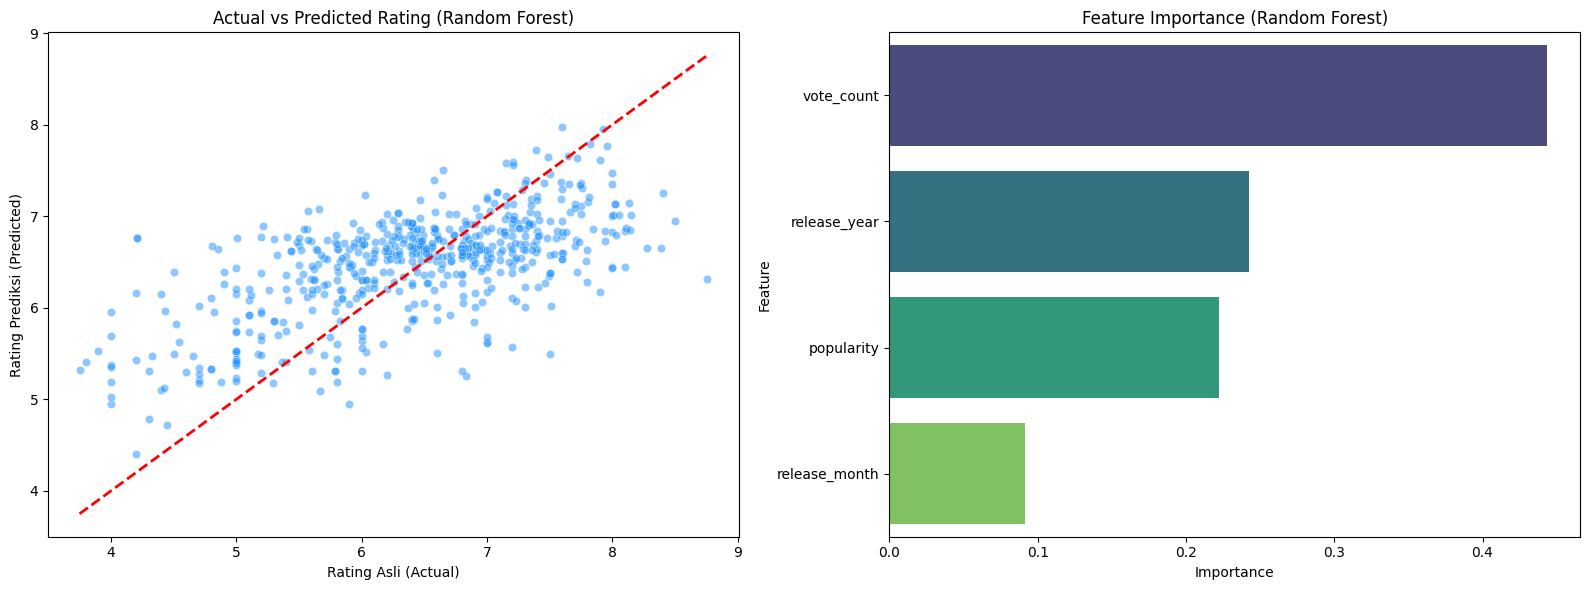

In [8]:
# ==========================================
# 10, 11. MODEL EVALUATION & COMPARISON
# ==========================================
print("\n--- Perbandingan Performa Model ---")
# Urutkan berdasarkan RMSE terkecil (error paling sedikit = paling bagus)
df_results = pd.DataFrame(results).sort_values(by="RMSE", ascending=True)
display(df_results)

# Otomatis memilih model terbaik berdasarkan RMSE terkecil
best_model_name = df_results.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n🌟 Model Terbaik Berdasarkan RMSE Terkecil: {best_model_name}")

# ==========================================
# 12. RESULT VISUALIZATION
# ==========================================
# Menggunakan prediksi dari model terbaik
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# a. Actual vs Predicted Plot
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5, ax=axes[0], color='dodgerblue')
# Garis ideal merah (jika tebakan 100% akurat, titik-titik akan berada di garis ini)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted Rating ({best_model_name})')
axes[0].set_xlabel('Rating Asli (Actual)')
axes[0].set_ylabel('Rating Prediksi (Predicted)')

# b. Feature Importance
importances = best_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', ax=axes[1])
axes[1].set_title(f'Feature Importance ({best_model_name})')

plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# 13. CONCLUSION
# ==========================================
from IPython.display import Markdown, display

display(Markdown("---"))
display(Markdown("### 🎬 KESIMPULAN PENELITIAN PREDIKSI RATING FILM"))
display(Markdown("---"))

# 1. Menampilkan Model Terbaik
display(Markdown(f"**1. Algoritma Terbaik:** Berdasarkan evaluasi metrik (RMSE terkecil), model terbaik untuk dataset ini adalah **{best_model_name}**."))

# 2. Menampilkan Pengaruh Fitur (Dengan pengaman Anti-Error)
try:
    top_feature = feature_imp_df.iloc[0]['Feature']
    display(Markdown(f"**2. Pengaruh Fitur:** Dari grafik Feature Importance, terbukti bahwa fitur **'{top_feature}'** memiliki pengaruh paling besar dalam menentukan rating sebuah film."))
except NameError:
    # Jika feature_imp_df gagal dibuat di langkah sebelumnya (misal karena Ensemble yang menang)
    display(Markdown("**2. Pengaruh Fitur:** Model terbaik saat ini adalah model Ensemble (Gabungan). Analisis kepentingan fitur tunggal tidak dapat diterapkan secara langsung pada model gabungan."))

# 3 dan 4. Saran & Kesimpulan Lainnya
display(Markdown("**3. Pipeline Sukses:** Seluruh tahapan dari Data Collection, Preprocessing, Training, hingga Tracking dengan MLflow telah berjalan dengan baik dan terekam."))

display(Markdown("**4. Saran Pengembangan:** Untuk penelitian selanjutnya, akurasi model dapat ditingkatkan dengan menambahkan fitur tambahan dari dataset asli, seperti genre film, durasi (runtime), atau budget produksi."))
display(Markdown("---"))

---

### 🎬 KESIMPULAN PENELITIAN PREDIKSI RATING FILM

---

**1. Algoritma Terbaik:** Berdasarkan evaluasi metrik (RMSE terkecil), model terbaik untuk dataset ini adalah **Random Forest**.

**2. Pengaruh Fitur:** Dari grafik Feature Importance, terbukti bahwa fitur **'vote_count'** memiliki pengaruh paling besar dalam menentukan rating sebuah film.

**3. Pipeline Sukses:** Seluruh tahapan dari Data Collection, Preprocessing, Training, hingga Tracking dengan MLflow telah berjalan dengan baik dan terekam.

**4. Saran Pengembangan:** Untuk penelitian selanjutnya, akurasi model dapat ditingkatkan dengan menambahkan fitur tambahan dari dataset asli, seperti genre film, durasi (runtime), atau budget produksi.

---

In [10]:
# ==========================================
# 14. SAVE BEST MODEL
# ==========================================
import joblib

# Menyimpan model terbaik secara otomatis sesuai hasil evaluasi (apa pun yang menang)
joblib.dump(best_model, 'model_pdm_terbaik.pkl')

# Menampilkan nama model yang berhasil disimpan agar kita yakin tidak salah simpan
print(f"✅ Model pemenang ({best_model_name}) berhasil disimpan sebagai 'model_pdm_terbaik.pkl' di folder utama!")

✅ Model pemenang (Random Forest) berhasil disimpan sebagai 'model_pdm_terbaik.pkl' di folder utama!
